Objective of EDA
-->To bring out of the quality of the data and make it ready for ML modeling

In [2]:
import numpy as np
import pandas as pd

In [3]:
data=pd.read_csv('titanic.csv')
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [6]:
data.dtypes;
data.select_dtypes(include='object');
data.select_dtypes(include='int');
data.select_dtypes(include=['int','float'])

C:\Users\chinn\AppData\Local\Temp\ipykernel_24964\28025203.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.select_dtypes(include='object');


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250
3,4,1,1,35.0,1,0,53.1000
4,5,0,3,35.0,0,0,8.0500
...,...,...,...,...,...,...,...
886,887,0,2,27.0,0,0,13.0000
887,888,1,1,19.0,0,0,30.0000
888,889,0,3,NaN,1,2,23.4500
889,890,1,1,26.0,0,0,30.0000


In [7]:
  print(len(data))

891


In [8]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
data.describe(include='object')

C:\Users\chinn\AppData\Local\Temp\ipykernel_24964\3382516499.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include='object')


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [10]:
data['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [11]:
data['Age'].unique()

array([22.  , 38.  , 26.  , 35.  ,   nan, 54.  ,  2.  , 27.  , 14.  ,
        4.  , 58.  , 20.  , 39.  , 55.  , 31.  , 34.  , 15.  , 28.  ,
        8.  , 19.  , 40.  , 66.  , 42.  , 21.  , 18.  ,  3.  ,  7.  ,
       49.  , 29.  , 65.  , 28.5 ,  5.  , 11.  , 45.  , 17.  , 32.  ,
       16.  , 25.  ,  0.83, 30.  , 33.  , 23.  , 24.  , 46.  , 59.  ,
       71.  , 37.  , 47.  , 14.5 , 70.5 , 32.5 , 12.  ,  9.  , 36.5 ,
       51.  , 55.5 , 40.5 , 44.  ,  1.  , 61.  , 56.  , 50.  , 36.  ,
       45.5 , 20.5 , 62.  , 41.  , 52.  , 63.  , 23.5 ,  0.92, 43.  ,
       60.  , 10.  , 64.  , 13.  , 48.  ,  0.75, 53.  , 57.  , 80.  ,
       70.  , 24.5 ,  6.  ,  0.67, 30.5 ,  0.42, 34.5 , 74.  ])

In [12]:
import matplotlib.pyplot as plt

[30. 17. 15.  9. 29. 64. 67. 70. 83. 62. 51. 40. 35. 27. 35. 23. 15.  9.
 11. 11.  4.  2.  3.  1.  1.]
<BarContainer object of 25 artists>


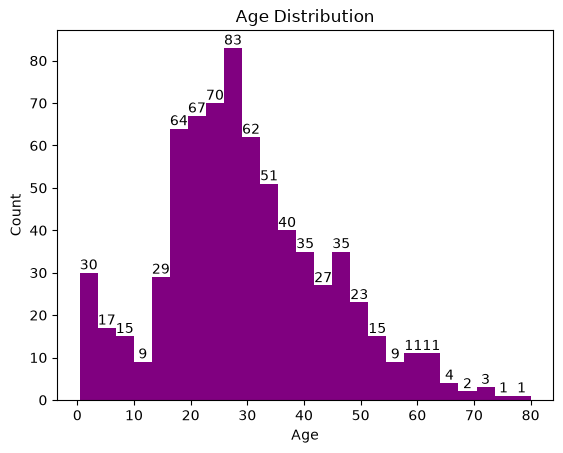

In [13]:
#Distribution of Age
#Display the count on bars in histogram
counts,edges,bars = plt.hist(data['Age'],bins=25,color='purple')
print(counts)
print(bars)
plt.xlabel("Age")
plt.ylabel("Count")
plt.bar_label(bars)
plt.title("Age Distribution")
plt.show()

<Axes: xlabel='Sex'>

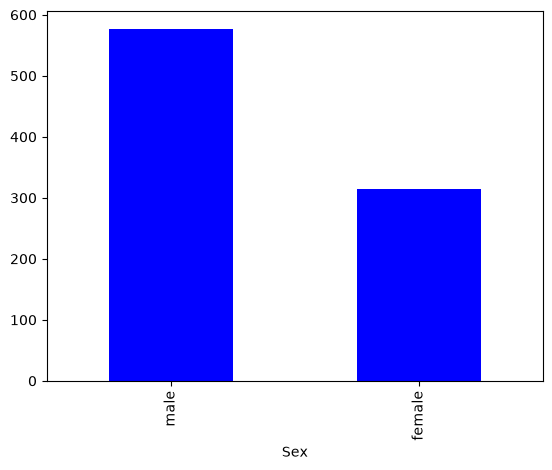

In [14]:
data['Sex'].value_counts().plot(kind='bar',color='blue')

<Axes: xlabel='Sex'>

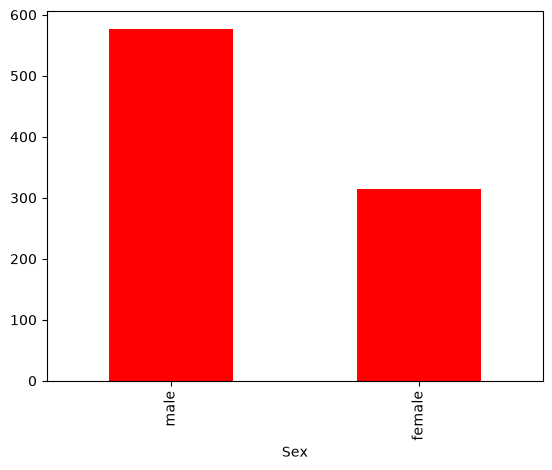

In [15]:
#Bar Plot Representation(Only For Objects(Categorical data))
data['Sex'].value_counts().plot(kind = 'bar',color='red')

<Axes: xlabel='Sex'>

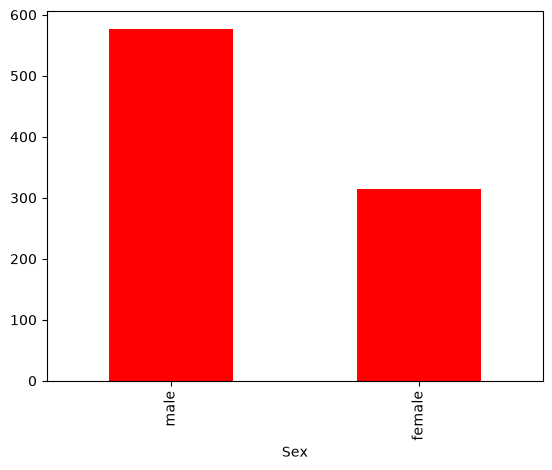

In [16]:
#Bar Plot Representation(Only For Objects(Categorical data))
data['Sex'].value_counts().plot(kind = 'bar',color='red')

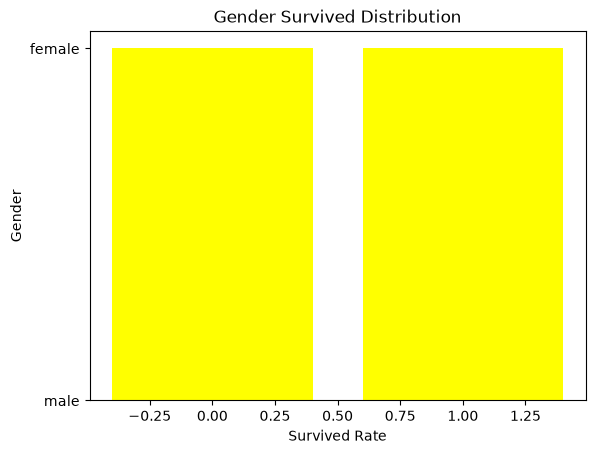

In [17]:
#Bar Plot Representation of Survived vs Sex
plt.bar(data['Survived'],data['Sex'],color = 'yellow')
plt.xlabel("Survived Rate")
plt.ylabel("Gender")
plt.title("Gender Survived Distribution")
plt.show()

In [18]:
data['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [19]:
#index-->keys(coloumn)
#labels-->values

#549/(549+342)
index = data['Survived'].value_counts().keys().tolist()
print(index)
labels = data['Survived'].value_counts().values.tolist()
print(labels)

[0, 1]
[549, 342]


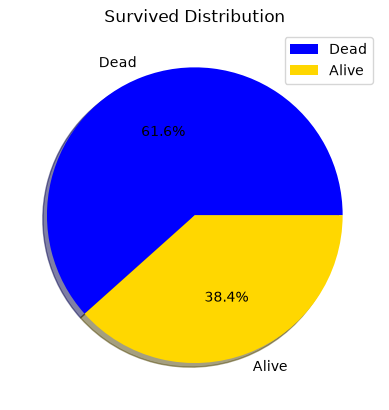

In [20]:
#Pie Charts For Column Survive
plt.pie(x = labels,
        labels = ['Dead','Alive'],
        colors = ['blue','gold'],
        autopct = "%.1f%%",
         shadow = True)
plt.title('Survived Distribution')
plt.legend()
plt.show()

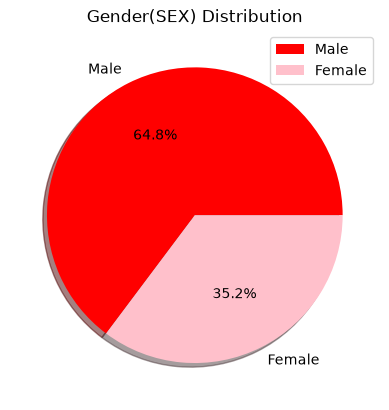

In [21]:
#Pie Charts For Column Sex
plt.pie(x = [577,314],
        labels = ['Male','Female'],
        colors = ['red','pink'],
        autopct = "%.1f%%",
         shadow = True)
plt.title('Gender(SEX) Distribution')
plt.legend()
plt.show()

In [22]:
!pip install cuffLinks

In [23]:
import plotly as py
import plotly.graph_objects as go

In [24]:
from plotly.offline import init_notebook_mode,iplot
init_notebook_mode(connected = True)

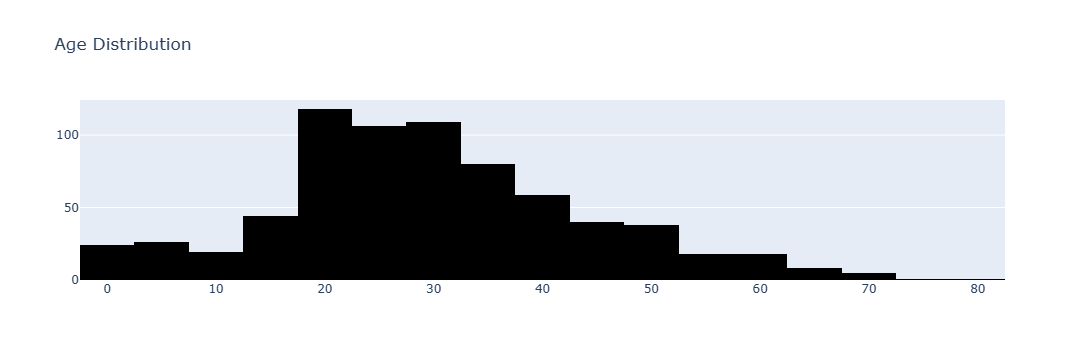

In [25]:
#Let's Visualize the histogram
trace = go.Histogram(x = data['Age'],
                     nbinsx=20,
                     marker={'color':'black'})
#Layout define for the graph
layout = go.Layout(title="Age Distribution")
#we combine the trace with the layout to display the figure
fig = go.Figure(data = trace,layout = layout)
fig

In [26]:
print(index)
print(labels)

[0, 1]
[549, 342]


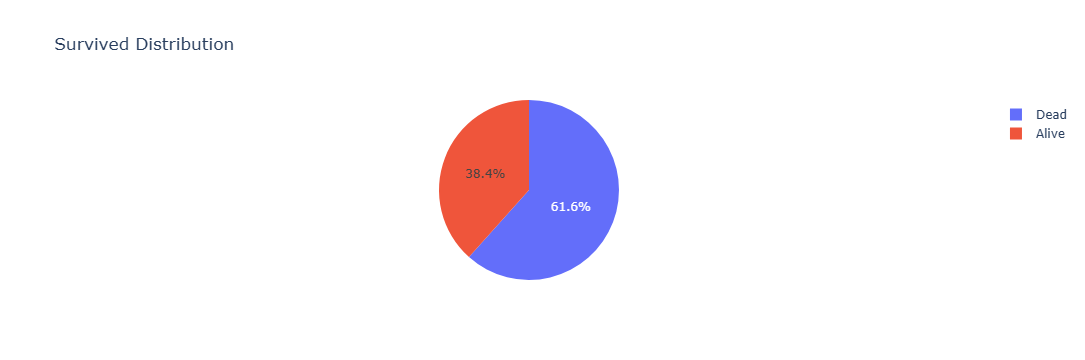

In [27]:
#Now We Will Dislay For Pie Chart
trace = go.Pie(labels = ['Dead','Alive'],
               values = [549,342],)
layout = go.Layout(title = 'Survived Distribution')
fig = go.Figure(data = trace,layout = layout)
fig.show()

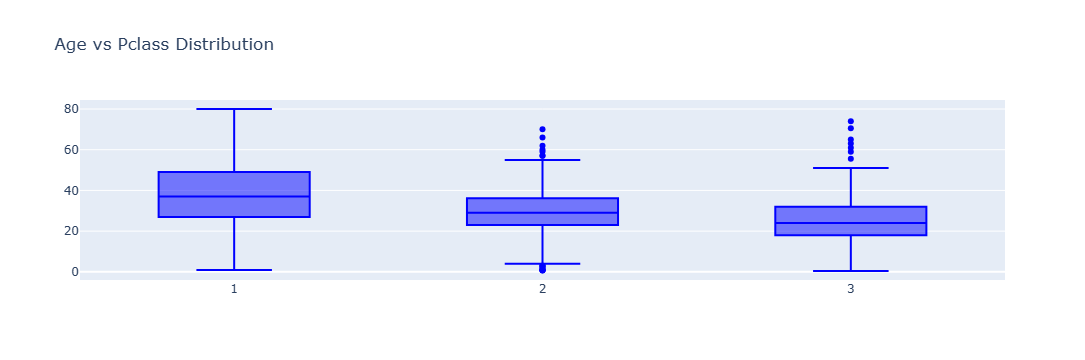

In [28]:
#Box Plot and Scatter Plot
trace = go.Box(x = data['Pclass'],
    y = data['Age'],
    marker = {'color':'blue'})
layout = go.Layout(title = "Age vs Pclass Distribution")
fig = go.Figure(data = trace, layout = layout)
fig.show()

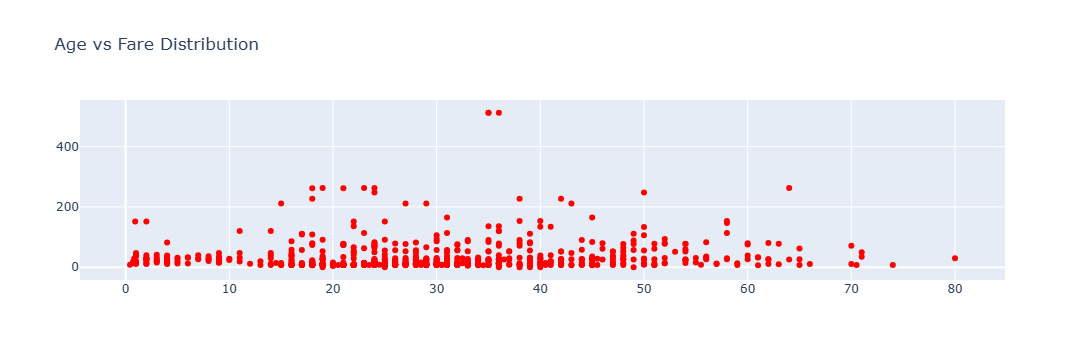

In [29]:
#Scatter Plot representation ----> Age vs Fare
trace = go.Scatter(x = data['Age'],y = data['Fare'],
                   mode = 'markers',
                   marker = {'color':'red'})
layout = go.Layout(
    title = "Age vs Fare Distribution")
fig = go.Figure(data = trace,layout=layout)
fig.show()

In [30]:
#Understanding the missing
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [31]:
print(data['Age'].mean())

29.69911764705882


In [32]:
#We can Fill the Age Coloumn 
data['Age'] = data['Age'].fillna(data['Age'].mean(),inplace = True)
data.isnull().sum()

C:\Users\chinn\AppData\Local\Temp\ipykernel_24964\2668615199.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['Age'] = data['Age'].fillna(data['Age'].mean(),inplace = True)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [33]:
data['Embarked'] = data['Embarked'].fillna('S')

In [34]:
data['Age'] = data['Age'].fillna(data['Age'].mean());
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [35]:
data.drop(columns = ['Cabin'],inplace = True)
data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [36]:
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,C


In [37]:
#Get Dummies  of Colomns(Pclass)
pclass = pd.get_dummies(data['Pclass'],drop_first = True,dtype = int)
pclass

,2,3
0,0,1
1,0,0
2,0,1
3,0,0
4,0,1
...,...,...
886,1,0
887,0,0
888,0,1
889,0,0


In [38]:
#Get Dummies  of Colomns(Embarked)
embark = pd.get_dummies(data['Embarked'],dtype = int,drop_first = True)
embark

,Q,S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1
...,...,...
886,0,1
887,0,1
888,0,1
889,0,0


In [39]:
#Get Dummies  of Colomns(Sex)
sex = pd.get_dummies(data['Sex'],dtype = int)
sex

,female,male
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
886,0,1
887,1,0
888,1,0
889,0,1


In [40]:
final_data = pd.concat([data,pclass,sex,embark],axis = 1)
final_data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,2,3,female,male,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,S,0,1,0,1,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C,0,0,1,0,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,S,0,1,1,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,S,0,0,1,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,S,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.000000,0,0,211536,13.0000,S,1,0,0,1,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.000000,0,0,112053,30.0000,S,0,0,1,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.699118,1,2,W./C. 6607,23.4500,S,0,1,1,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",male,26.000000,0,0,111369,30.0000,C,0,0,0,1,0,0


In [42]:
final_data.drop(columns = ['PassengerId','Name',
                           'Pclass','Sex','Ticket',
                           'Embarked'],inplace = True)

KeyError: "['PassengerId', 'Name', 'Pclass', 'Sex', 'Ticket', 'Embarked'] not found in axis"

In [43]:
final_data.head()

,Survived,Age,SibSp,Parch,Fare,2,3,female,male,Q,S
0,0,22.0,1,0,7.2500,0,1,0,1,0,1
1,1,38.0,1,0,71.2833,0,0,1,0,0,0
2,1,26.0,0,0,7.9250,0,1,1,0,0,1
3,1,35.0,1,0,53.1000,0,0,1,0,0,1
4,0,35.0,0,0,8.0500,0,1,0,1,0,1
